In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Part (a)**

$$T = \frac{m_0}{\alpha}$$

Instantaneous mass of the rocket:

$0 \leq t \leq T$

$$m(t) = \text{Mass of rocket + Mass of fuel} \\ = 2m_0 - \alpha t$$

$T \leq t \leq 2T$

$$m(t) = \text{Mass of rocket} = m_0$$

## **Part (b)**

Suppose there is a mass $m$ moving with a velocity $v$ towards the right. In this case, right is taken to be the positive direction.

*Initial momentum:*

$$p_i = mv$$

After a time $dt$, it ejects a mass $dm$ with velocity $u$ in the opposite(left) direction. Its velocity becomes $v+dv$.

*Final momentum:*

$$p_f = \text{Momentum of mass m + Momentum of mass dm} \\ 
= (m-dm)(v+dv) - udm$$

(-ve sign is taken as $dm$ moves in opposite direction).

*Change in momentum:*

$$dp = p_f - p_i \\
= (m-dm)(v+dv) - udm - mv \\
= mdv - (v + u + dv)dm$$

Suppose that the mass $dm$ moves with a velocity $v_{rel}$ relative to $m$

$$v_{rel} = u - (-v - dv) = u + v + dv$$

Hence,

$$dp = mdv - v_{rel}dm$$

*External force:*

$$F_{ext} = \frac{dp}{dt}
= m\frac{dv}{dt} - v_{rel}\frac{dm}{dt}$$

**Phase 1:**

$F_{ext} = -\gamma v \\ 
\frac{dm}{dt} = \alpha \\
m = 2m_0 - \alpha t$

*Final equation:*

$$(2m_0 - \alpha t)\frac{dv}{dt} = v_{rel} \alpha - \gamma v$$

**Phase 2**:

$\frac{dm}{dt} = 0$

*Final equation:*

$$m_0 \frac{dv}{dt} = -\gamma v$$

## **Part (c)**

$$(2m_0 - \alpha t)\frac{dv}{dt} = \alpha v_{rel} - \gamma v \\[10 pt]

\implies \int_0^v \frac{dv}{\alpha v_{rel} - \gamma v} = \int_0^t \frac{dt}{2m_0 - \alpha t} \\[10 pt]

\implies -\frac{1}{\gamma} \left[ln(\alpha v_{rel} - \gamma v)\right]_0^v = -\frac{1}{\alpha} \left[ln(2m_0 - \alpha t)\right]_0^t \\[10 pt]

\implies ln\left(\frac{\alpha v_{rel} - \gamma v}{\alpha v_{rel}}\right) = \frac{\gamma}{\alpha} \, ln\left(\frac{2m_0 - \alpha t}{2m_0}\right) \\[10 pt]

\implies 1 - \frac{\gamma v}{\alpha v_{rel}} = \left(1 - \frac{\alpha t}{2m_0}\right)^{\frac{\gamma}{\alpha}} \\[10 pt]

\implies v(t) = \frac{\alpha v_{rel}}{\gamma} \left[1 - \left(1 - \frac{t}{2T}\right)^{\frac{\gamma}{\alpha}}\right]$$

*If $\gamma \rightarrow 0$*:

$$(2m_0 - \alpha t)\frac{dv}{dt} = \alpha v_{rel} \\[10 pt]

\implies \int_0^v dv = \alpha v_{rel} \int_0^t \frac{dt}{2m_0 - \alpha t} \\[10 pt]

\implies v(t) = -v_{rel} \, ln\left(\frac{2m_0 - \alpha t}{2m_0}\right) \\[10 pt]

\implies v(t) = v_{rel} \, ln\left(\frac{2m_0}{2m_0 - \alpha t}\right)
$$

## **Part (d)**

For phase 2:
$$
m_0 \frac{dv}{dt} = -\gamma v \\[10 pt]

\implies \int_{v_1}^v \frac{dv}{v} = - \frac{\gamma}{m_0} \int_T^t dt \\[10 pt]

\implies ln\left(\frac{v}{v_1}\right) = -\frac{\gamma}{m_0}(t-T) \\[10 pt]

\implies v(t) = v_1 \, exp\left(-\frac{\gamma}{m_0}(t-T)\right)
$$

**Case 1: $\gamma = 0$**

$$
v_1 = v(T) = v_{rel} \, ln\left(\frac{2m_0}{2m_0 - m_0}\right) \\[10 pt]

\implies v_1 = v_{rel} \, ln\,2
$$

(using $\alpha T = m_0$)

**Case 2: $\gamma \neq 0$**

$$
v_1 = \frac{v_{rel}\alpha}{\gamma} \left[1 - \left(1 - \frac{T}{2T}\right)^{\frac{\gamma}{\alpha}}\right] \\[10 pt]

\implies v_1 = \frac{v_{rel}\alpha}{\gamma} \left[1 - 2^{-\frac{\gamma}{\alpha}}\right]
$$

**Part (e)**

In [ ]:
# Parameters
m0 = 1.0
alpha = 1.0
vrel = 1.0
T = m0/alpha
v0 = np.array([0.0])

# Time grid
ti, tf = 0, 2*T
dt = 1e-3
N = int((tf - ti)/dt) + 1
ts = np.linspace(ti, tf, N)

From previous expressions:

**Phase 1:**

$$\frac{dv}{dt} = \frac{\alpha v_{rel} - \gamma v}{2m_0 - \alpha t}$$

**Phase 2:**

$$\frac{dv}{dt} = - \frac{\gamma v}{m_0}$$

Implementing RK4

In [45]:
# RK4
def rk4(f1, x, y, h, gamma):
    k1 = h * f1(x, y, gamma)
    k2 = h * f1(x + h / 2, y + k1 / 2, gamma)
    k3 = h * f1(x + h / 2, y + k2 / 2, gamma)
    k4 = h * f1(x + h, y + k3, gamma)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# RK4 caller
def caller(fn, y_ini, N, xs, h, gamma):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = rk4(fn, x, y, h, gamma)
    return ys

# dv/dt
def f1(t, v, gamma):
    # Phase 1
    if (t >=0 and t <= T):
        return (vrel*alpha - gamma*v)/(2*m0 - alpha*t)
    # Phase 2
    else:
        return -(gamma*v)/m0


In [ ]:
# Implementing RK4 for different gamma
vs0 = caller(f1, v0, N, ts, dt, gamma=0)
vs1 = caller(f1, v0, N, ts, dt, gamma=alpha/2)
vs2 = caller(f1, v0, N, ts, dt, gamma=alpha)

Exact velocity

In [35]:
# Exact velocity function
def exact(t, gamma):
    if gamma == 0:
        # Phase 1
        if (t >= 0 and t <= T):
            return vrel*np.log(2*m0/(2*m0 - alpha*t))
        # Phase 2
        else:
            return vrel*np.log(2)
    else:
        # Phase 1
        if (t >= 0 and t <= T):
            return (alpha*vrel)*(1 - (1 - t/2*T)**(gamma/alpha))/gamma
        # Phase 2
        else:
            return (vrel*alpha)*(1 - 2**(-gamma/alpha))*np.exp(-gamma/m0*(t - T))/gamma

# Exact velocities for different gamma
exact0 = [exact(t, gamma=0) for t in ts]
exact1 = [exact(t, gamma=alpha/2) for t in ts]
exact2 = [exact(t, gamma=alpha) for t in ts]

**Part (f):** Plotting

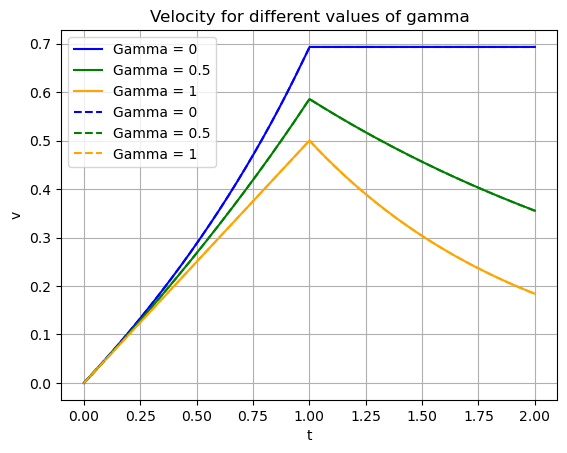

In [36]:
# Numerical solution
plt.plot(ts, vs0, color = "blue", label = "Gamma = 0")
plt.plot(ts, vs1, color = "green", label = f"Gamma = {alpha/2}")
plt.plot(ts, vs2, color = "orange", label = f"Gamma = {alpha}")

# Analytical solution
plt.plot(ts, exact0, color = "blue", linestyle = '--', label = "Gamma = 0")
plt.plot(ts, exact1, color = "green", linestyle = '--', label = f"Gamma = {alpha/2}")
plt.plot(ts, exact2, color = "orange", linestyle = '--', label = f"Gamma = {alpha}")

plt.title("Velocity for different values of gamma")
plt.xlabel("t")
plt.ylabel("v")
plt.legend()
plt.grid()
plt.show()


## **Part (g):**

From previous expression for **Phase 1** when $\gamma \neq 0$

$$(2m_0 - \alpha t) \frac{dv}{dt} = \alpha v_{rel} - \gamma v$$

Terminal velocity occurs when

$$\frac{dv}{dt} = 0 \\

\implies v_{term} = \frac{\alpha v_{rel}}{\gamma}
$$

During **Phase 1** at $t = T$:

$$v(T) = \frac{\alpha v_{rel}}{\gamma} \left[1 - \left(\frac{1}{2}\right)^{\frac{\gamma}{\alpha}}\right]$$

$$\frac{v(T)}{v_{term}} = 1 - \left(\frac{1}{2}\right)^{\frac{\gamma}{\alpha}}$$

$\gamma = \frac{\alpha}{2}:$
$$v(T) \approx 0.586 \, v_{term}$$

$\gamma = \alpha:$
$$v(T) = 0.5 \, v_{term}$$

Hence the rocket never reaches $v_{term}$ in Phase 1.

## **Part (h):**

The differential equations for velocity and position are:

$$
\frac{dx}{dt} = v \\[10 pt]
\frac{dv}{dt} = \frac{\alpha v_{rel} - \gamma v}{2m_0 - \alpha t}
$$

They can be combined and written in matrix form as:

$$\frac{d}{dt} 
\begin{pmatrix}
    x \\
    v
\end{pmatrix}
= 
\begin{pmatrix}
    v \\
    \frac{\alpha v_{rel} - \gamma v}{2m_0 - \alpha t}
\end{pmatrix}
$$

If we denote $x = y[0]$ and $v = y[1]$, then

$$
\frac{d}{dt} 
\begin{pmatrix}
    y[0] \\
    y[1]
\end{pmatrix}
= 
\begin{pmatrix}
    y[1] \\
    \frac{\alpha v_{rel} - \gamma y[1]}{2m_0 - \alpha t}
\end{pmatrix}
$$

In [47]:
# d/dt[x v]
def f2(t, y, gamma):
    # Phase 1
    if (t >=0 and t <= T):
        return np.asarray([y[1], (vrel*alpha - gamma*y[1])/(2*m0 - alpha*t)])
    # Phase 2
    else:
        return np.asarray([y[1], -(gamma*y[1])/m0])

# Implementing RK4
Y0 = np.array([0, 0])
ys0 = caller(f2, Y0, N, ts, dt, gamma=0)
ys1 = caller(f2, Y0, N, ts, dt, gamma=alpha/2)
ys2 = caller(f2, Y0, N, ts, dt, gamma=alpha)

Plotting

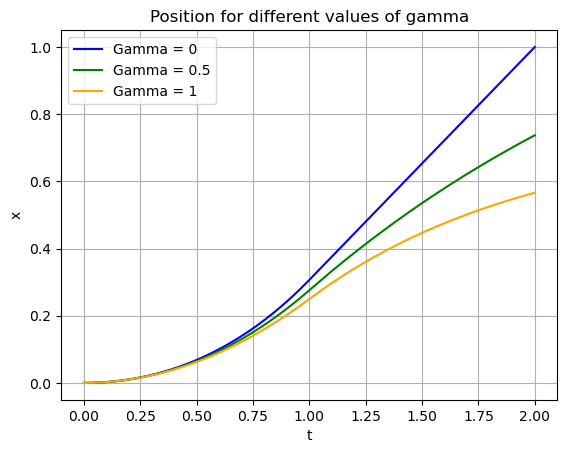

In [50]:
# Numerical solution
plt.plot(ts, ys0[:, 0], color = "blue", label = "Gamma = 0")
plt.plot(ts, ys1[:, 0], color = "green", label = f"Gamma = {alpha/2}")
plt.plot(ts, ys2[:, 0], color = "orange", label = f"Gamma = {alpha}")

plt.title("Position for different values of gamma")
plt.xlabel("t")
plt.ylabel("x")
plt.legend()
plt.grid()
plt.show()